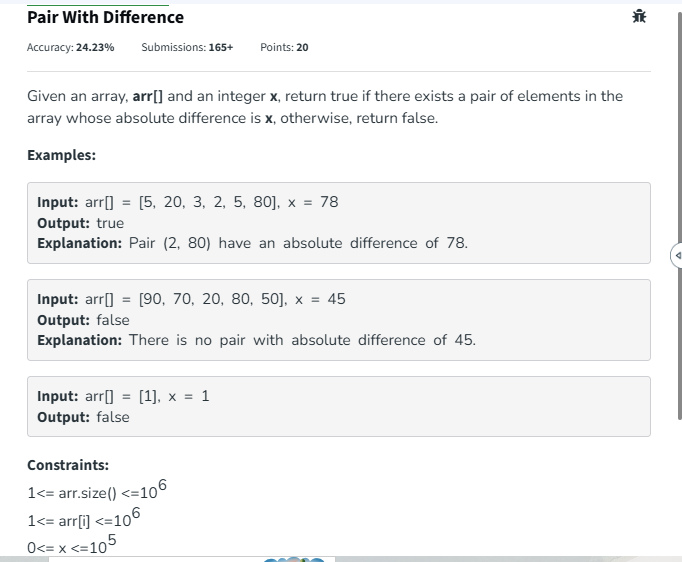

Algorithm Logic

The code checks if there exists a pair (a, b) in the array such that |a - b| = x.

Store Elements: It creates a set s containing all unique elements of the array for $O(1)$ average time complexity lookups.

Iterate and Check: For every number num in the array, it checks if a "complement" exists in the set.

The complement could be num + x (if num is the smaller element).

The complement could be num - x (if num is the larger element).

Handle Edge Case ($x = 0$): If the difference x is 0, we are looking for two identical numbers. The code explicitly checks arr.count(num) > 1 to ensure the number appears at least twice in the original array, preventing a number from pairing with itself in the set.



Input: arr = [5, 20, 3, 2, 50, 80], x = 78 Expected Output: True (Pair is {2, 80})

| Step | Variable `num` | Condition Check: `(num + x) in s` OR `(num - x) in s` | Special Check (`x != 0`) | Result |
| :--- | :--- | :--- | :--- | :--- |
| **Init** | `s = {2, 3, 5, 20, 50, 80}` | | | |
| 1 | `5` | Is `5+78=83` in `s`? **No**.<br>Is `5-78=-73` in `s`? **No**. | - | Continue |
| 2 | `20` | Is `20+78=98` in `s`? **No**.<br>Is `20-78=-58` in `s`? **No**. | - | Continue |
| 3 | `3` | Is `3+78=81` in `s`? **No**.<br>Is `3-78=-75` in `s`? **No**. | - | Continue |
| 4 | `2` | Is `2+78=80` in `s`? **Yes** (`80` exists). | `78 != 0` is **True**. | **Return `True`** |

In [ ]:
from typing import List

class Solution:
    def findPair(self, arr, x):
        s = set(arr)

        for num in arr:
            if (num + x) in s or (num - x) in s:
                if x != 0 or arr.count(num) > 1:
                    return True

        return False

Algorithm Logic

This approach relies on the fact that the array is sorted.

Sort: The array is sorted in ascending order.

Two Pointers: Initialize i (left) at 0 and j (right) at 1.

Calculate Difference: Compute diff = arr[j] - arr[i] (since sorted, arr[j] >= arr[i], so abs is technically redundant but safe).

Adjust Pointers:
If diff < x: The difference is too small. We need a larger number, so increment j.
If diff > x: The difference is too large. We need a smaller difference, so increment i.
If diff == x: Pair found, return True.
Safety Check: If i equals j, increment j to ensure we are comparing two distinct elements.

Input: arr = [1, 8, 30, 40, 100], x = 60 Expected Output: True (Pair is {40, 100})


| Step | `i` | `j` | `arr[i]` | `arr[j]` | `diff` (`arr[j]-arr[i]`) | Comparison (`diff` vs `x=60`) | Action |
| :--- | :-: | :-: | :---: | :---: | :---: | :--- | :--- |
| 1 | 0 | 1 | 1 | 8 | 7 | $7 < 60$ | `j++` (Need larger diff) |
| 2 | 0 | 2 | 1 | 30 | 29 | $29 < 60$ | `j++` |
| 3 | 0 | 3 | 1 | 40 | 39 | $39 < 60$ | `j++` |
| 4 | 0 | 4 | 1 | 100 | 99 | $99 > 60$ | `i++` (Diff too big) |
| 5 | 1 | 4 | 8 | 100 | 92 | $92 > 60$ | `i++` |
| 6 | 2 | 4 | 30 | 100 | 70 | $70 > 60$ | `i++` |
| 7 | 3 | 4 | 40 | 100 | **60** | $60 == 60$ | **Return `True`** |

In [ ]:

from typing import List
class Solution:
    def findPair(self, arr: List[int], x: int) -> int:
        # code here
        
        arr.sort()
        
        i=0
        j=1
        
        while  j<len(arr) and  i<len(arr):
            
            if i==j:
                j+=1
                continue
            
            diff=abs(arr[i]-arr[j])
            
            if diff<x:
                j+=1
            elif diff>x:
                i+=1
            else:
                return True
                
        return False
        

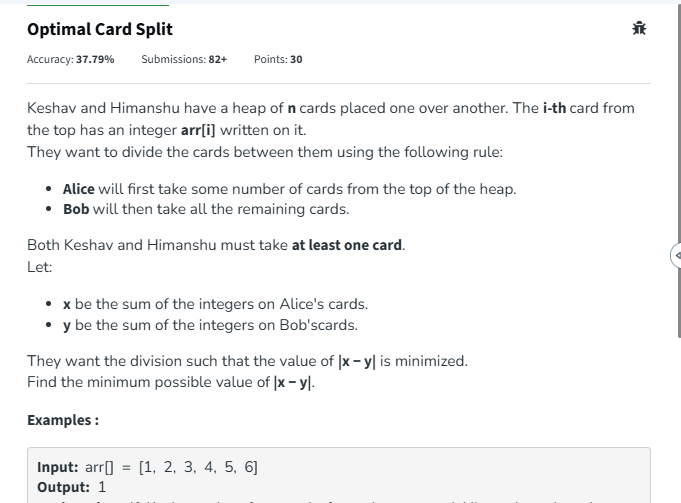
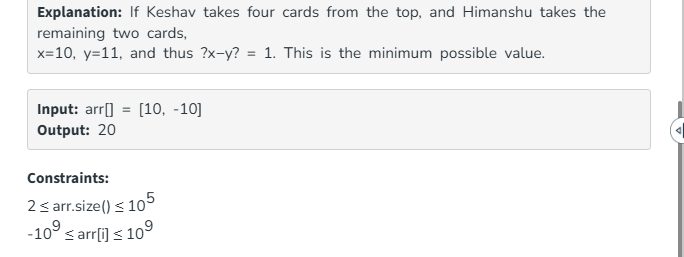

Algorithm Logic

Calculate the total sum of the array.

Iterate through the array up to the second-to-last element (len(arr) - 1) to ensure the right partition is never empty.

Maintain a running prefix sum for the left part.
    
The sum of the right part is implicitly total - prefix.

The difference is |prefix - (total - prefix)|, which simplifies to |2 * prefix - total|.
Track the minimum difference found. 

The loop runs from i = 0 to i = 3 (len(arr) - 2), ensuring the right partition always has at least one card.

|Variable |	Initial Value|
| :---: | :---: |
|total	|15 (Sum of [1, 2, 3, 4, 5])|
|prefix	|0|
|ans	|∞ (Infinity)|


| Iteration | i | arr[i] | prefix (Left Sum) | Right Sum | Calculation | diff | New ans |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 1 | 0 | 1 | 1 | 14 | `abs(2*1 - 15) = 13` | 13 | 13 |
| 2 | 1 | 2 | 3 | 12 | `abs(2*3 - 15) = 9` | 9 | 9 |
| 3 | 2 | 3 | 6 | 9 | `abs(2*6 - 15) = 3` | 3 | 3 |
| 4 | 3 | 4 | 10 | 5 | `abs(2*10 - 15) = 5` | 5 | 3 |

In [ ]:
class Solution:
    def miniDifference(self, arr):
        total = sum(arr)

        prefix = 0
        ans = float('inf')

        # both should get at least one card
        for i in range(len(arr) - 1):
            prefix += arr[i]

            diff = abs(2 * prefix - total)

            ans = min(ans, diff)

        return ans

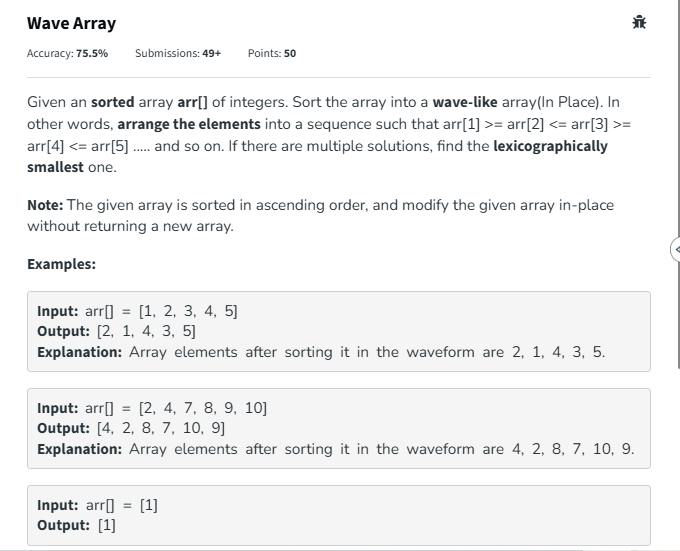
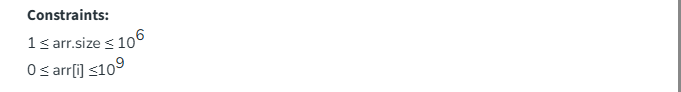

In [ ]:
class Solution:
    def sortInWave(self, arr):
        
        n = len(arr)

        for i in range(0, n - 1, 2):
            arr[i], arr[i + 1] = arr[i + 1], arr[i]

        return arr
        